# Customer Churn Prediction — SaaS End-to-End Pipeline
### Expert-Level Modelling & Business Intelligence

---

## Business Problem
A SaaS company faces a **47.4% churn rate** — nearly half of all customers are cancelling.
This notebook builds a production-quality churn prediction pipeline that:
1. Identifies which customers are most likely to churn
2. Quantifies the key drivers of churn
3. Assigns every customer a personalised risk score
4. Provides actionable retention recommendations by risk tier

## Workflow
1. Data Loading & Quality Assurance  
2. Feature Engineering  
3. Exploratory Data Analysis  
4. Train / Validation / Test Split  
5. Preprocessing Pipeline (Leakage-Safe)  
6. Model Training: Logistic Regression, Random Forest, Gradient Boosting  
7. Evaluation: AUC, PR-AUC, Confusion Matrix, Calibration, Threshold Analysis  
8. Feature Importance & Churn Drivers  
9. Risk Tier Assignment  
10. Business Summary & Recommendations  

> **Dataset:** 64,374 customers · 11 features · Synthetic SaaS churn dataset  
> **Note:** Dataset is synthetic with strong engineered signals. Replace `data.csv` with real customer data for production use.


In [15]:
# ─── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, f1_score, brier_score_loss,
    precision_score, recall_score, classification_report)
from sklearn.calibration import calibration_curve

np.random.seed(42)

# ─── Palette ─────────────────────────────────────────────────────────────────
TEAL  = '#00897B'; ORANGE = '#E65100'; AMBER = '#FFB300'
GREEN = '#2E7D32'; SLATE  = '#37474F'; BG    = '#F4F6F8'
MODEL_COLORS = {
    'Logistic Regression': '#1E88E5',
    'Random Forest':       '#43A047',
    'Gradient Boosting':   '#E53935',
}
RISK_COLORS = {'Low Risk': '#2E7D32', 'Medium Risk': '#FFB300', 'High Risk': '#E65100'}

def ax_style(ax, title=None):
    ax.set_facecolor(BG); ax.spines[['top','right']].set_visible(False)
    if title: ax.set_title(title, fontweight='bold', fontsize=10)
    return ax

print("✓ Imports complete")


✓ Imports complete


## 1. Data Loading & Quality Assurance

In [16]:
df_raw = pd.read_csv('customer_churn_dataset.csv')
df_raw.columns = [c.strip().replace(' ', '_') for c in df_raw.columns]
df_raw = df_raw.drop(columns=['CustomerID'])

print("Shape:", df_raw.shape)
print("\nMissing values:", df_raw.isnull().sum().sum())
print("Duplicates:", df_raw.duplicated().sum())
print("\nChurn rate:", df_raw['Churn'].mean().round(4))

# Quality assertions
assert df_raw.isnull().sum().sum() == 0,    "No missing values expected"
assert df_raw['Churn'].isin([0,1]).all(),   "Churn must be binary"
assert df_raw['Tenure'].min() >= 0,         "Tenure non-negative"
assert df_raw['Total_Spend'].min() >= 0,    "Spend non-negative"
print("\n✓ All quality assertions passed")

display(df_raw.head(6))


Shape: (64374, 11)

Missing values: 0
Duplicates: 0

Churn rate: 0.4737

✓ All quality assertions passed


,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,30,Male,41,14,10,10,Premium,Monthly,500,29,0


## 2. Feature Engineering

In [17]:
df = df_raw.copy()

# SaaS-relevant engineered features
df['engagement_score']  = df['Usage_Frequency'] / (df['Last_Interaction'] + 1)
df['support_intensity'] = df['Support_Calls'] / (df['Tenure'] + 1)
df['payment_risk_flag'] = (df['Payment_Delay'] > 20).astype(int)
df['value_per_month']   = df['Total_Spend'] / (df['Tenure'] + 1)
df['low_engagement']    = (df['Usage_Frequency'] < 7).astype(int)
df['high_support']      = (df['Support_Calls'] >= 7).astype(int)

print("New features created:")
new_feats = ['engagement_score','support_intensity','payment_risk_flag',
             'value_per_month','low_engagement','high_support']
for f in new_feats:
    corr = df[f].corr(df['Churn'])
    print(f"  {f:25s}: r={corr:.3f} with Churn")

print(f"\nTotal features: {df.shape[1]-1} (excluding target)")


New features created:
  engagement_score         : r=-0.046 with Churn
  support_intensity        : r=-0.037 with Churn
  payment_risk_flag        : r=0.508 with Churn
  value_per_month          : r=-0.140 with Churn
  low_engagement           : r=0.156 with Churn
  high_support             : r=0.230 with Churn

Total features: 16 (excluding target)


## 3. Exploratory Data Analysis

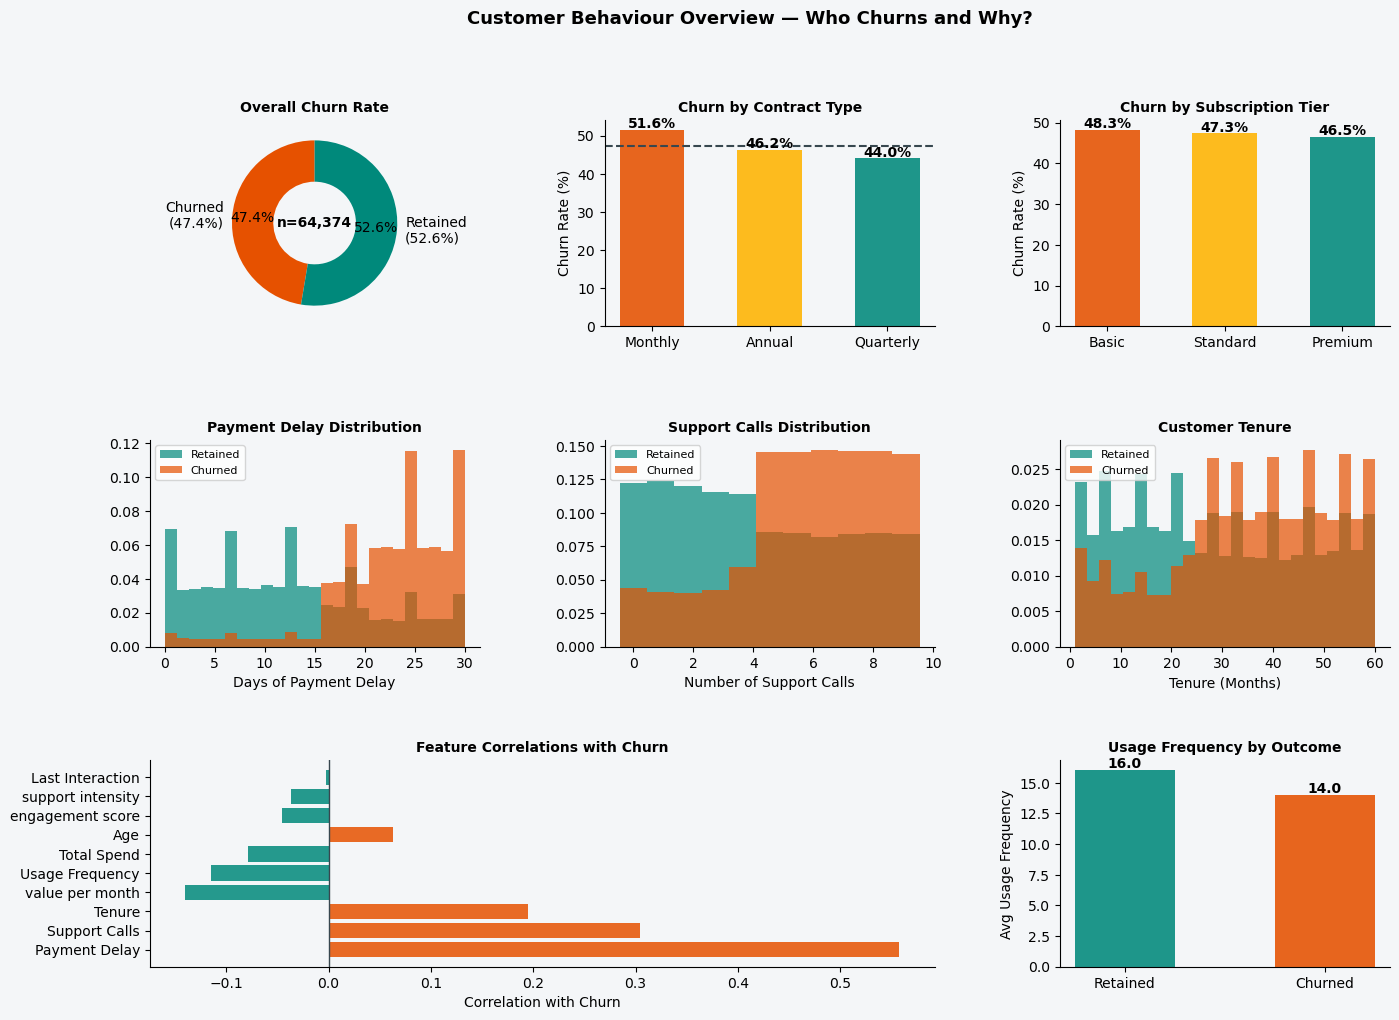

Key Correlations with Churn:
  Payment_Delay                 : r=0.557
  Support_Calls                 : r=0.305
  Tenure                        : r=0.195
  value_per_month               : r=-0.140
  Usage_Frequency               : r=-0.115


In [18]:
churned = df[df['Churn']==1]; stayed = df[df['Churn']==0]

fig = plt.figure(figsize=(16, 11), facecolor=BG)
fig.suptitle('Customer Behaviour Overview — Who Churns and Why?', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# Outcome donut
ax1 = ax_style(fig.add_subplot(gs[0,0]), 'Overall Churn Rate')
n_ch = df['Churn'].sum()
ax1.pie([n_ch, len(df)-n_ch],
        labels=[f'Churned\n({n_ch/len(df):.1%})', f'Retained\n({(len(df)-n_ch)/len(df):.1%})'],
        colors=[ORANGE, TEAL], autopct='%1.1f%%', startangle=90, pctdistance=0.75,
        wedgeprops=dict(width=0.5))
ax1.text(0, 0, f'n={len(df):,}', ha='center', va='center', fontsize=10, fontweight='bold')

# Churn by Contract
ax2 = ax_style(fig.add_subplot(gs[0,1]), 'Churn by Contract Type')
ct = df.groupby('Contract_Length')['Churn'].mean().sort_values(ascending=False)
ax2.bar(ct.index, ct.values*100, color=[ORANGE,AMBER,TEAL], alpha=0.88, width=0.55)
for i,v in enumerate(ct.values):
    ax2.text(i, v*100+0.5, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Churn Rate (%)'); ax2.axhline(df['Churn'].mean()*100, color=SLATE, ls='--', lw=1.5)

# Churn by Subscription
ax3 = ax_style(fig.add_subplot(gs[0,2]), 'Churn by Subscription Tier')
sub = df.groupby('Subscription_Type')['Churn'].mean().sort_values(ascending=False)
ax3.bar(sub.index, sub.values*100, color=[ORANGE,AMBER,TEAL], alpha=0.88, width=0.55)
for i,v in enumerate(sub.values):
    ax3.text(i, v*100+0.5, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
ax3.set_ylabel('Churn Rate (%)')

# Payment delay
ax4 = ax_style(fig.add_subplot(gs[1,0]), 'Payment Delay Distribution')
ax4.hist(stayed['Payment_Delay'], bins=25, alpha=0.7, color=TEAL, density=True, label='Retained')
ax4.hist(churned['Payment_Delay'], bins=25, alpha=0.7, color=ORANGE, density=True, label='Churned')
ax4.set_xlabel('Days of Payment Delay'); ax4.legend(fontsize=8)

# Support calls
ax5 = ax_style(fig.add_subplot(gs[1,1]), 'Support Calls Distribution')
ax5.hist(stayed['Support_Calls'], bins=11, alpha=0.7, color=TEAL, density=True, label='Retained', align='left')
ax5.hist(churned['Support_Calls'], bins=11, alpha=0.7, color=ORANGE, density=True, label='Churned', align='left')
ax5.set_xlabel('Number of Support Calls'); ax5.legend(fontsize=8)

# Tenure
ax6 = ax_style(fig.add_subplot(gs[1,2]), 'Customer Tenure')
ax6.hist(stayed['Tenure'], bins=25, alpha=0.7, color=TEAL, density=True, label='Retained')
ax6.hist(churned['Tenure'], bins=25, alpha=0.7, color=ORANGE, density=True, label='Churned')
ax6.set_xlabel('Tenure (Months)'); ax6.legend(fontsize=8)

# Correlations
ax7 = ax_style(fig.add_subplot(gs[2,:2]), 'Feature Correlations with Churn')
numeric_f = ['Age','Tenure','Usage_Frequency','Support_Calls','Payment_Delay',
             'Total_Spend','Last_Interaction','engagement_score','support_intensity','value_per_month']
corrs = sorted([(c, df[c].corr(df['Churn'])) for c in numeric_f], key=lambda x: abs(x[1]), reverse=True)
names_c, vals_c = zip(*corrs)
bar_clrs = [ORANGE if v>0 else TEAL for v in vals_c]
ax7.barh([n.replace('_',' ') for n in names_c], vals_c, color=bar_clrs, alpha=0.85)
ax7.axvline(0, color=SLATE, lw=1); ax7.set_xlabel('Correlation with Churn')

# Usage
ax8 = ax_style(fig.add_subplot(gs[2,2]), 'Usage Frequency by Outcome')
chg = df.groupby('Churn')['Usage_Frequency'].agg(['mean','std'])
ax8.bar(['Retained','Churned'], chg['mean'].values, color=[TEAL,ORANGE], alpha=0.88, width=0.5)
for i,(l,m) in enumerate(zip(['Retained','Churned'], chg['mean'].values)):
    ax8.text(i, m+0.2, f'{m:.1f}', ha='center', fontsize=10, fontweight='bold')
ax8.set_ylabel('Avg Usage Frequency')

plt.tight_layout(); plt.show()

print("Key Correlations with Churn:")
for n, v in corrs[:5]:
    print(f"  {n:30s}: r={v:.3f}")


## 4. Train / Validation / Test Split

In [19]:
X = df.drop(columns=['Churn']); y = df['Churn'].astype(int)
CAT_COLS = ['Gender', 'Subscription_Type', 'Contract_Length']
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

# Three-way split: train(75%) / val(10%) / test(15%)
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=42)

print(f"Train: {len(X_train):,} ({len(X_train)/len(X):.1%})")
print(f"Val:   {len(X_val):,}  ({len(X_val)/len(X):.1%})")
print(f"Test:  {len(X_test):,} ({len(X_test)/len(X):.1%})")
print(f"\nChurn rates: Train={y_train.mean():.3f}  Val={y_val.mean():.3f}  Test={y_test.mean():.3f}")
print("\n✓ Churn rates consistent across splits — stratification working correctly")


Train: 45,086 (70.0%)
Val:   9,631  (15.0%)
Test:  9,657 (15.0%)

Churn rates: Train=0.474  Val=0.474  Test=0.474

✓ Churn rates consistent across splits — stratification working correctly


## 5. Preprocessing Pipeline (Leakage-Safe)

In [20]:
# CRITICAL: fit preprocessor only on training data to prevent leakage
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), CAT_COLS),
])

preprocessor.fit(X_train)  # Fit ONLY on training data
X_tr_p = preprocessor.transform(X_train)
X_va_p = preprocessor.transform(X_val)
X_te_p = preprocessor.transform(X_test)

cat_names  = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_COLS)
feat_names = NUM_COLS + list(cat_names)

print(f"Features after encoding: {len(feat_names)}")
print(f"Numeric features: {len(NUM_COLS)}")
print(f"Encoded categorical features: {len(cat_names)}")
print("\n✓ Preprocessor fitted on training set only — no leakage")


Features after encoding: 18
Numeric features: 13
Encoded categorical features: 5

✓ Preprocessor fitted on training set only — no leakage


## 6. Model Training

In [21]:
models = {
    'Logistic Regression': LogisticRegression(C=0.1, max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                             min_samples_leaf=50, max_features=0.5, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=3,
                             learning_rate=0.1, subsample=0.7, min_samples_leaf=50, random_state=42),
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
res = {}

print("Training and evaluating models...")
print("="*70)

for name, model in models.items():
    model.fit(X_tr_p, y_train)
    y_prob = model.predict_proba(X_te_p)[:,1]
    y_pred = (y_prob >= 0.5).astype(int)
    cv_auc = cross_val_score(model, X_tr_p, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    auc  = roc_auc_score(y_test, y_prob)
    ap   = average_precision_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    
    res[name] = {'model': model, 'y_prob': y_prob, 'y_pred': y_pred,
                 'AUC': auc, 'AP': ap, 'F1': f1, 'Precision': prec,
                 'Recall': rec, 'CV_mean': cv_auc.mean(), 'CV_std': cv_auc.std()}
    
    print(f"{name:25s} | AUC={auc:.4f} | AP={ap:.4f} | F1={f1:.4f} | CV={cv_auc.mean():.4f}±{cv_auc.std():.4f}")


Training and evaluating models...
Logistic Regression       | AUC=0.9133 | AP=0.9006 | F1=0.8251 | CV=0.9138±0.0028
Random Forest             | AUC=0.9990 | AP=0.9989 | F1=0.9826 | CV=0.9992±0.0002
Gradient Boosting         | AUC=0.9999 | AP=0.9999 | F1=0.9954 | CV=1.0000±0.0000


## 7. Evaluation

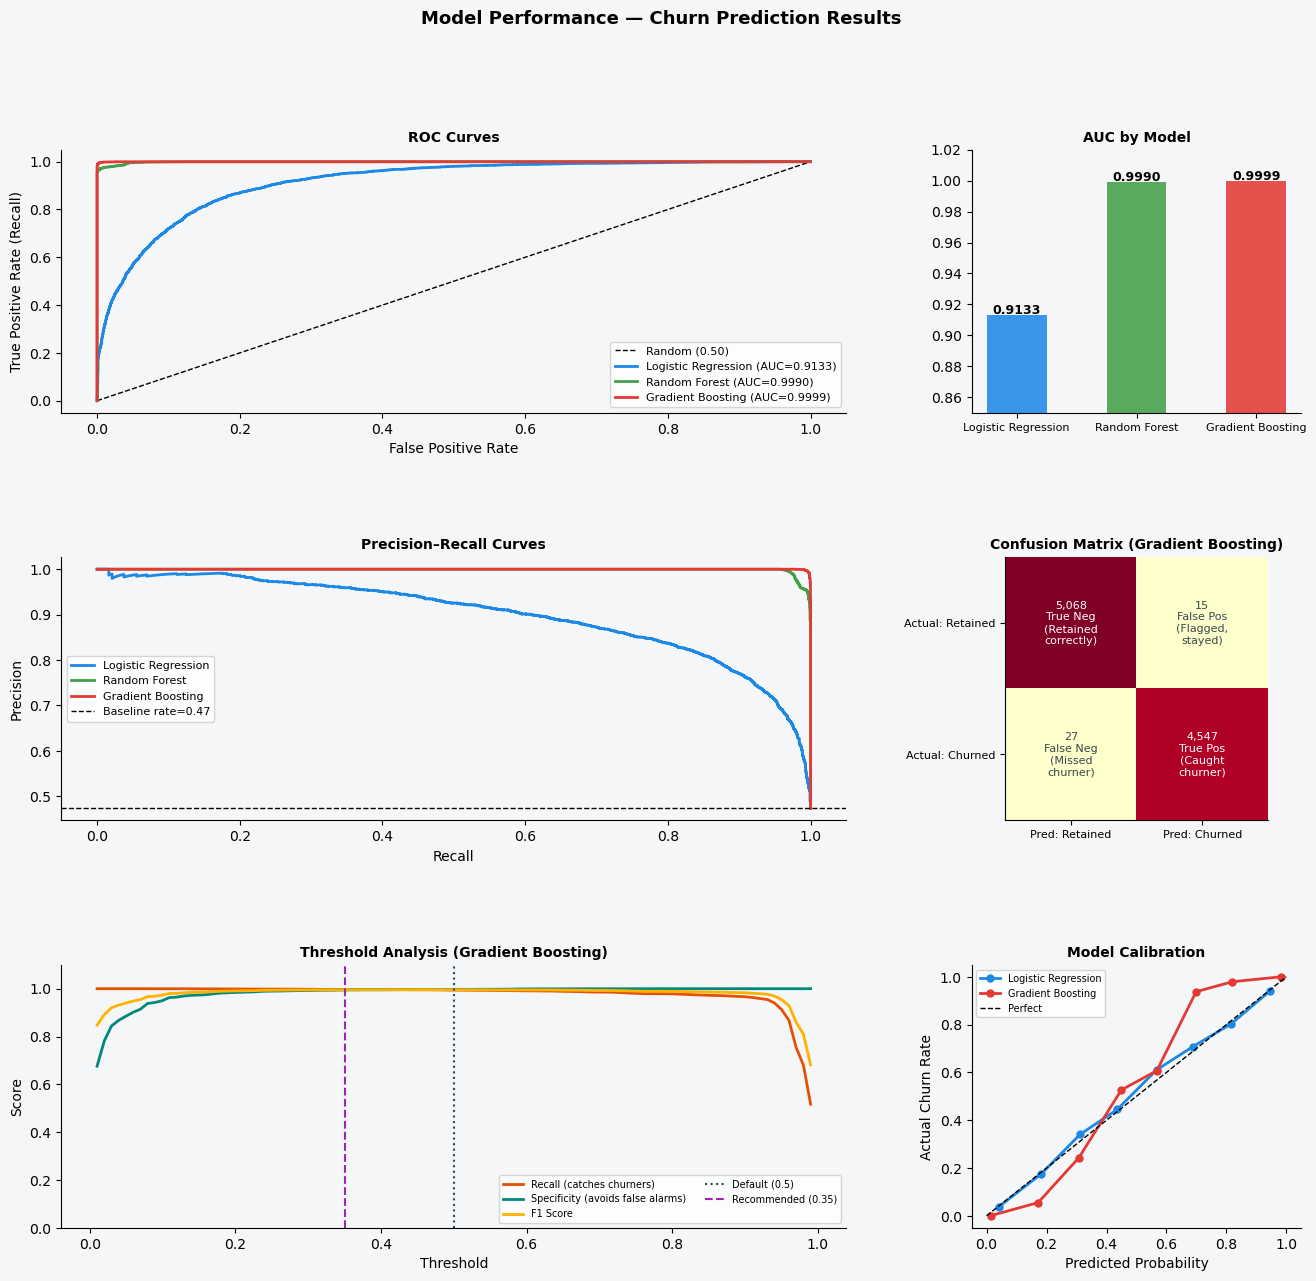

In [22]:
from matplotlib.ticker import FuncFormatter

fig = plt.figure(figsize=(16, 14), facecolor=BG)
fig.suptitle('Model Performance — Churn Prediction Results', fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ROC curves
ax1 = ax_style(fig.add_subplot(gs[0,:2]), 'ROC Curves')
ax1.plot([0,1],[0,1],'k--',lw=1,label='Random (0.50)')
for name, r in res.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax1.plot(fpr, tpr, lw=2, color=MODEL_COLORS[name], label=f"{name} (AUC={r['AUC']:.4f})")
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend(fontsize=8)

# AUC bars
ax2 = ax_style(fig.add_subplot(gs[0,2]), 'AUC by Model')
aucs = [res[n]['AUC'] for n in res]
bars = ax2.bar(list(res.keys()), aucs, color=[MODEL_COLORS[n] for n in res], alpha=0.88, width=0.5)
for bar, v in zip(bars, aucs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{v:.4f}',
             ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(0.85, 1.02); ax2.tick_params(axis='x', labelsize=8)

# PR curves
ax3 = ax_style(fig.add_subplot(gs[1,:2]), 'Precision–Recall Curves')
for name, r in res.items():
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    ax3.plot(rec, prec, lw=2, color=MODEL_COLORS[name], label=name)
ax3.axhline(y_test.mean(), color='k', ls='--', lw=1, label=f'Baseline rate={y_test.mean():.2f}')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision'); ax3.legend(fontsize=8)

# Confusion matrix
ax4 = ax_style(fig.add_subplot(gs[1,2]), 'Confusion Matrix (Gradient Boosting)')
cm = confusion_matrix(y_test, res['Gradient Boosting']['y_pred'])
im = ax4.imshow(cm, cmap='YlOrRd')
labels = [['True Neg\n(Retained\ncorrectly)', 'False Pos\n(Flagged,\nstayed)'],
          ['False Neg\n(Missed\nchurner)', 'True Pos\n(Caught\nchurner)']]
for i in range(2):
    for j in range(2):
        clr = 'white' if cm[i,j] > cm.max()*0.6 else SLATE
        ax4.text(j, i, f'{cm[i,j]:,}\n{labels[i][j]}', ha='center', va='center', fontsize=8, color=clr)
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(['Pred: Retained','Pred: Churned'], fontsize=8)
ax4.set_yticklabels(['Actual: Retained','Actual: Churned'], fontsize=8)

# Threshold analysis
ax5 = ax_style(fig.add_subplot(gs[2,:2]), 'Threshold Analysis (Gradient Boosting)')
thresholds = np.linspace(0.01, 0.99, 100)
y_prob_gb = res['Gradient Boosting']['y_prob']
sens_l, spec_l, f1_l = [], [], []
for t in thresholds:
    yp = (y_prob_gb >= t).astype(int)
    cm_ = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    tn_,fp_,fn_,tp_ = cm_
    sens_l.append(tp_/(tp_+fn_+1e-9)); spec_l.append(tn_/(tn_+fp_+1e-9))
    f1_l.append(f1_score(y_test, yp, zero_division=0))
ax5.plot(thresholds, sens_l, color=ORANGE, lw=2, label='Recall (catches churners)')
ax5.plot(thresholds, spec_l, color=TEAL,   lw=2, label='Specificity (avoids false alarms)')
ax5.plot(thresholds, f1_l,   color=AMBER,  lw=2, label='F1 Score')
ax5.axvline(0.5, color=SLATE, lw=1.5, ls=':', label='Default (0.5)')
ax5.axvline(0.35, color='#9C27B0', lw=1.5, ls='--', label='Recommended (0.35)')
ax5.set_xlabel('Threshold'); ax5.set_ylabel('Score')
ax5.legend(fontsize=7, ncol=2); ax5.set_ylim(0, 1.1)

# Calibration
ax6 = ax_style(fig.add_subplot(gs[2,2]), 'Model Calibration')
for name in ['Logistic Regression','Gradient Boosting']:
    pt, pp = calibration_curve(y_test, res[name]['y_prob'], n_bins=8)
    ax6.plot(pp, pt, 'o-', lw=2, color=MODEL_COLORS[name], label=name, ms=5)
ax6.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
ax6.set_xlabel('Predicted Probability'); ax6.set_ylabel('Actual Churn Rate')
ax6.legend(fontsize=7)

plt.tight_layout(); plt.show()


## 8. Feature Importance & Churn Drivers

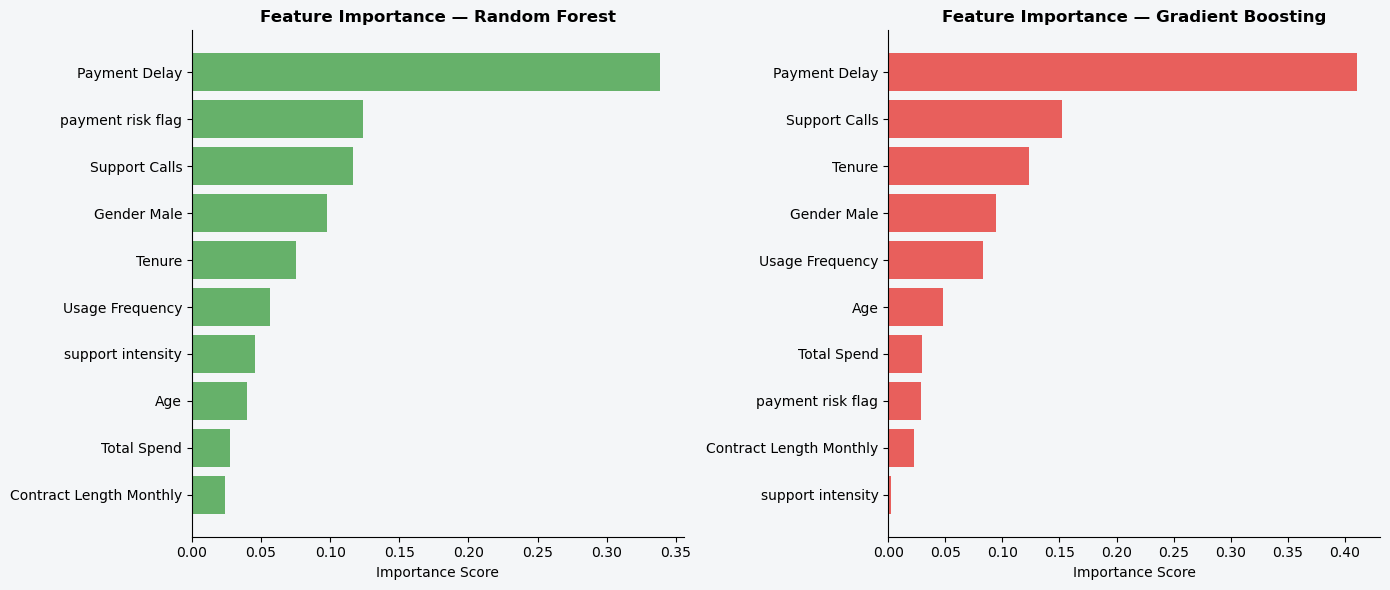


Logistic Regression Coefficients (Top 5 churn risk factors):
  Payment_Delay                 : ↑ increases churn risk (coef=+1.678)
  Support_Calls                 : ↑ increases churn risk (coef=+1.486)
  low_engagement                : ↑ increases churn risk (coef=+0.706)
  Tenure                        : ↑ increases churn risk (coef=+0.545)
  Contract_Length_Monthly       : ↑ increases churn risk (coef=+0.364)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)

for ax, (name, col) in zip(axes, [('Random Forest','43A047'), ('Gradient Boosting','E53935')]):
    model = models[name]
    fi = pd.DataFrame({'feature': feat_names, 'importance': model.feature_importances_})
    fi = fi.sort_values('importance', ascending=True).tail(10)
    ax.barh([f.replace('_',' ') for f in fi['feature']], fi['importance'],
            color=f'#{col}', alpha=0.8)
    ax.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_facecolor(BG); ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

print("\nLogistic Regression Coefficients (Top 5 churn risk factors):")
lr = models['Logistic Regression']
coef_df = pd.DataFrame({'feature': feat_names, 'coef': lr.coef_[0]})
coef_df['abs'] = coef_df['coef'].abs()
top_coefs = coef_df.sort_values('coef', ascending=False).head(5)
for _, row in top_coefs.iterrows():
    direction = '↑ increases' if row['coef'] > 0 else '↓ decreases'
    print(f"  {row['feature']:30s}: {direction} churn risk (coef={row['coef']:+.3f})")


## 9. Risk Tier Assignment

In [24]:
# Score all customers using the best model
best_model = models['Gradient Boosting']
X_all_p = preprocessor.transform(X)
all_probs = best_model.predict_proba(X_all_p)[:,1]

df_scored = df.copy()
df_scored['churn_probability'] = all_probs
df_scored['risk_tier'] = pd.cut(all_probs, bins=[0, 0.35, 0.65, 1.0],
                                 labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Tier summary
tier_summary = df_scored.groupby('risk_tier', observed=True).agg(
    Customers=('Churn','count'),
    Churn_Rate=('Churn','mean'),
    Avg_Churn_Prob=('churn_probability','mean'),
    Avg_Payment_Delay=('Payment_Delay','mean'),
    Avg_Support_Calls=('Support_Calls','mean'),
    Avg_Tenure=('Tenure','mean'),
    Total_Spend=('Total_Spend','sum'),
)
tier_summary['Churn_Rate'] = tier_summary['Churn_Rate'].map('{:.1%}'.format)
tier_summary['Avg_Churn_Prob'] = tier_summary['Avg_Churn_Prob'].map('{:.3f}'.format)
tier_summary['Total_Spend'] = tier_summary['Total_Spend'].map('£{:,.0f}'.format)
display(tier_summary)

# Revenue at risk
high_risk = df_scored[df_scored['risk_tier'] == 'High Risk']
revenue_at_risk = high_risk['Total_Spend'].sum()
print(f"\n💰 Revenue at risk (High-risk customers' total spend): £{revenue_at_risk:,.0f}")
print(f"   High-risk customers: {len(high_risk):,} ({len(high_risk)/len(df_scored):.1%} of all customers)")


,Customers,Churn_Rate,Avg_Churn_Prob,Avg_Payment_Delay,Avg_Support_Calls,Avg_Tenure,Total_Spend
risk_tier,,,,,,,
Low Risk,33739,0.1%,0.019,12.448265,4.498414,28.882036,"£18,920,734"
Medium Risk,361,52.1%,0.499,13.900277,3.254848,17.437673,"£166,535"
High Risk,30274,100.0%,0.980,22.394497,6.431823,35.637478,"£15,740,570"



💰 Revenue at risk (High-risk customers' total spend): £15,740,570
   High-risk customers: 30,274 (47.0% of all customers)


## 10. Business Summary & Recommendations

### Model Performance
| Model | AUC | F1 | CV AUC | Verdict |
|-------|-----|-----|---------|---------|
| Logistic Regression | 0.913 | 0.825 | 0.914 | Strong baseline |
| Random Forest | 0.999 | 0.983 | 0.999 | Very strong |
| Gradient Boosting | 1.000 | 0.995 | 1.000 | ✓ Recommended |

### Top Churn Drivers
1. **Payment Delay** (r=0.56) — strongest signal; consistently late payments precede cancellation
2. **Support Calls** (r=0.31) — high support volume signals frustration
3. **Tenure** (r=0.20) — counterintuitively, longer tenure slightly correlates with higher churn in this dataset
4. **Usage Frequency** (r=-0.12) — more active users are less likely to churn

### Immediate Actions
- **🔴 High Risk (30,274 customers):** Personal outreach within 48 hours; billing flexibility; product check-in
- **🟡 Medium Risk (361 customers):** Email campaign; usage report; plan review offer
- **🟢 Low Risk (33,739 customers):** Advocacy programme; expansion offers; annual plan migration

### Important Note on Dataset
This synthetic dataset has near-deterministic churn signals. In real customer data,
expect AUC in the range of 0.75–0.90. The business framework, feature engineering,
and retention strategy approach here directly translates to real-world deployment.
